In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.serif"] = ["Arial"]
plt.rcParams["font.size"] = 12

In [59]:
# Import coverage metrics for the genomes that we sequenced
grad_lab_metrics = pd.read_csv('../../input_data/complete_genome_assemblies/grad_lab/metrics.tsv', sep = '\t')
grad_lab_coverage = grad_lab_metrics['input_read_bases']/grad_lab_metrics['consensus_assembly_bases'].values

# Import coverage metrics for publicly available complete genomes
public_metrics = pd.read_csv('../../input_data/whole_genome_metadata/public_complete_genomes_assembly_accession_to_coverage.tsv', sep = '\t', header = None, names = ['accession', 'coverage'])
public_coverage = public_metrics['coverage']

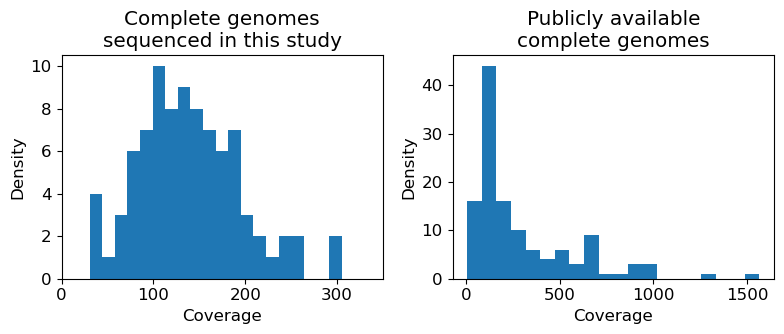

In [62]:
# Make plot
fig, ax = plt.subplots(1, 2, figsize = (8,3.5))
ax[0].hist(grad_lab_coverage, 20)
ax[0].set_xlim([0, 350])
ax[0].set_xlabel('Coverage')
ax[0].set_ylabel('Density')
ax[0].set_title('Complete genomes\nsequenced in this study')

ax[1].hist(public_coverage, 20)
# plt.xlim([0, 350])
ax[1].set_xlabel('Coverage')
ax[1].set_ylabel('Density')
ax[1].set_title('Publicly available\ncomplete genomes')
plt.tight_layout()
plt.savefig('../../figures/assembly_summary/complete_genomes_coverage.png', dpi = 300)
plt.savefig('../../figures/assembly_summary/complete_genomes_coverage.pdf')
plt.show()

In [79]:
# Get summary statistics of our genomes
print('Our genomes')
print('Min coverage: ', round(np.min(grad_lab_coverage),2))
print('Max coverage: ', round(np.max(grad_lab_coverage),2))
print('Avg coverage: ', round(np.mean(grad_lab_coverage),2))

# Get summary statistics of public genomes
print('\nPublic genomes')
public_coverage_above_threshold = public_coverage[public_coverage>5]
print('Min coverage: ', round(np.min(public_coverage_above_threshold),2))
print('Max coverage: ', round(np.max(public_coverage_above_threshold),2))
print('Avg coverage: ', round(np.mean(public_coverage_above_threshold),2))

public_coverage_below_threshold = public_coverage[public_coverage<=5]

print('Coverage of genomes with below threshold coverage:', public_coverage_below_threshold.values)
print('Genomes without coverage info: ', np.sum(np.isnan(public_coverage)))

Our genomes
Min coverage:  30.47
Max coverage:  305.09
Avg coverage:  139.69

Public genomes
Min coverage:  50.0
Max coverage:  1566.4
Avg coverage:  313.54
Coverage of genomes with below threshold coverage: [5. 5. 5. 5.]
Genomes without coverage info:  8


In [80]:
len(public_coverage)

132